In [ ]:
# Importamos las librerias necesarias
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
path = kagglehub.dataset_download('robikscube/hourly-energy-consumption')
df = pd.read_csv(Path(path) / 'PJM_Load_hourly.csv')

In [6]:
df.head()

,Datetime,energy_mw
0,1998-04-01 01:00:00,22259.0
1,1998-04-01 02:00:00,21244.0
2,1998-04-01 03:00:00,20651.0
3,1998-04-01 04:00:00,20421.0
4,1998-04-01 05:00:00,20713.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  object 
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), object(1)
memory usage: 514.1+ KB


In [ ]:
# Como la fehca es un string, la convertimos a datetime y ordenamos el dataframe por fecha
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Tambien reenombramos la columna de consumo para facilitar el uso 
df = df.rename(columns={'PJM_Load_MW': 'energy_mw'})

# visualizamos los cambios y las dimensiones del df 
print(df.shape, df.dtypes)
df.head()

(32896, 2) Datetime     datetime64[ns]
energy_mw           float64
dtype: object


,Datetime,energy_mw
0,1998-04-01 01:00:00,22259.0
1,1998-04-01 02:00:00,21244.0
2,1998-04-01 03:00:00,20651.0
3,1998-04-01 04:00:00,20421.0
4,1998-04-01 05:00:00,20713.0


In [10]:
# Estudiaremos con la siguiente funcion si existen valores nulos o duplicados en el dataframe
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores únicos': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores únicos
0,Datetime,32896,0,datetime64[ns],32896
1,energy_mw,32896,0,float64,16865


Observamos que no existen valores nulos ni duplicados en nuestro dataset, por tanto podemos proceder con el análisis, sin necesidad de imputar datos.

In [12]:
df["energy_mw"].describe()

count    32896.000000
mean     29766.427408
std       5849.769954
min      17461.000000
25%      25473.000000
50%      29655.000000
75%      33073.250000
max      54030.000000
Name: energy_mw, dtype: float64

In [17]:
# Ahora realizaremos Feature engineering, para esto extraeremos características temporales de la columna Datetime, como la hora, el día de la semana,
#  el mes, el año, el trimestre, el día del año y si es fin de semana o no. Estas características pueden ser útiles para capturar patrones estacionales 
# y de comportamiento en los datos de consumo energético.
df['hour']       = df['Datetime'].dt.hour
df['dayofweek']  = df['Datetime'].dt.dayofweek
df['month']      = df['Datetime'].dt.month
df['year']       = df['Datetime'].dt.year
df['quarter']    = df['Datetime'].dt.quarter
df['dayofyear']  = df['Datetime'].dt.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df.head()

,Datetime,energy_mw,hour,dayofweek,month,year,quarter,dayofyear,is_weekend
0,1998-04-01 01:00:00,22259.0,1,2,4,1998,2,91,0
1,1998-04-01 02:00:00,21244.0,2,2,4,1998,2,91,0
2,1998-04-01 03:00:00,20651.0,3,2,4,1998,2,91,0
3,1998-04-01 04:00:00,20421.0,4,2,4,1998,2,91,0
4,1998-04-01 05:00:00,20713.0,5,2,4,1998,2,91,0


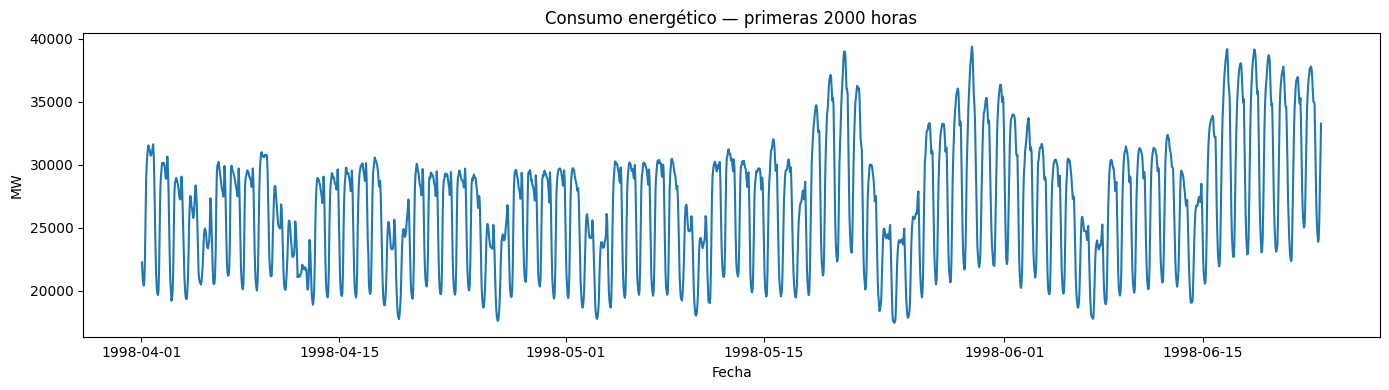

                            Datetime     energy_mw          hour  \
count                          32896  32896.000000  32896.000000   
mean   2000-02-15 12:40:57.490272512  29766.427408     11.502189   
min              1998-04-01 01:00:00  17461.000000      0.000000   
25%              1999-03-09 18:45:00  25473.000000      6.000000   
50%              2000-02-15 12:30:00  29655.000000     12.000000   
75%              2001-01-23 06:15:00  33073.250000     18.000000   
max              2002-01-01 00:00:00  54030.000000     23.000000   
std                              NaN   5849.769954      6.921706   

          dayofweek         month          year       quarter     dayofyear  \
count  32896.000000  32896.000000  32896.000000  32896.000000  32896.000000   
mean       3.000699      6.819705   1999.598979      2.607460    192.155733   
min        0.000000      1.000000   1998.000000      1.000000      1.000000   
25%        1.000000      4.000000   1999.000000      2.000000    109.00

In [18]:
#Ahora vamos  a visualizar la serie temporal de consumo energético para las primeras 2000 horas,
#  lo que nos permitirá observar patrones y tendencias en el consumo a lo largo del tiempo.
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'][:2000], df['energy_mw'][:2000])
plt.title('Consumo energético — primeras 2000 horas')
plt.xlabel('Fecha'); plt.ylabel('MW')
plt.tight_layout()
plt.savefig('../data/consumo_serie.png')
plt.show()
print(df.describe())